In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/clean_issues.csv")
print(f"Total rows: {len(df)}")
df.head()

Total rows: 1375


,text,label
0,[Error] unhandlederror-Problems parsing file i...,bug
1,[Error] unhandlederror-Failed to fetch\n\n## E...,bug
2,[Error] unhandlederror-SQLITE_NOTADB: sqlite3 ...,bug
3,[Error] unhandlederror-Failed to register a Se...,bug
4,[Error] [GitHub.copilot-chat] unhandlederror-A...,bug


label
bug                 550
info-needed         498
feature-request     145
triage-needed       128
ux                   39
under-discussion     15
Name: count, dtype: int64


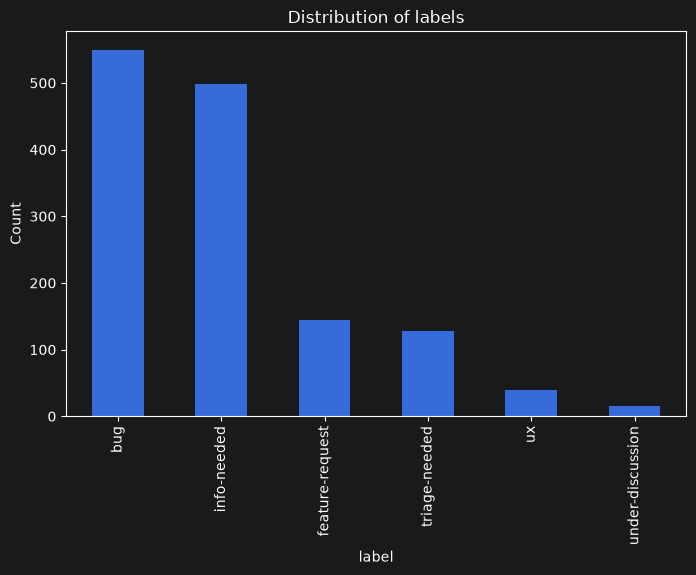

In [13]:
counts = df["label"].value_counts()
print(counts)

counts.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of labels")
plt.ylabel("Count")
plt.show()

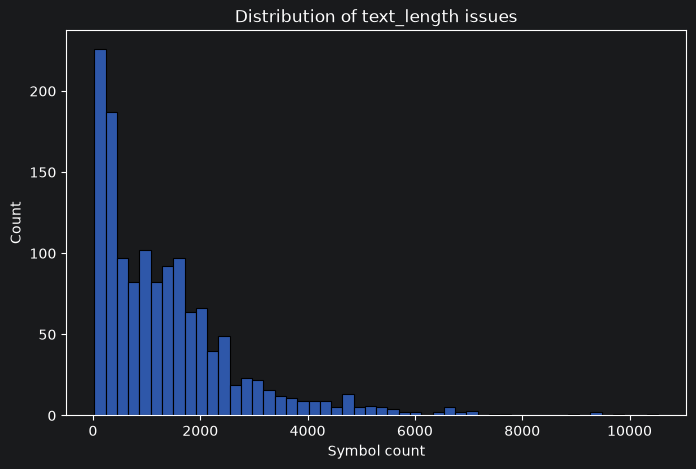

In [14]:
df["text_length"] = df["text"].str.len()
df["text_length"].describe()

plt.figure(figsize=(8, 5))

sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of text_length issues")
plt.xlabel("Symbol count")
plt.show()

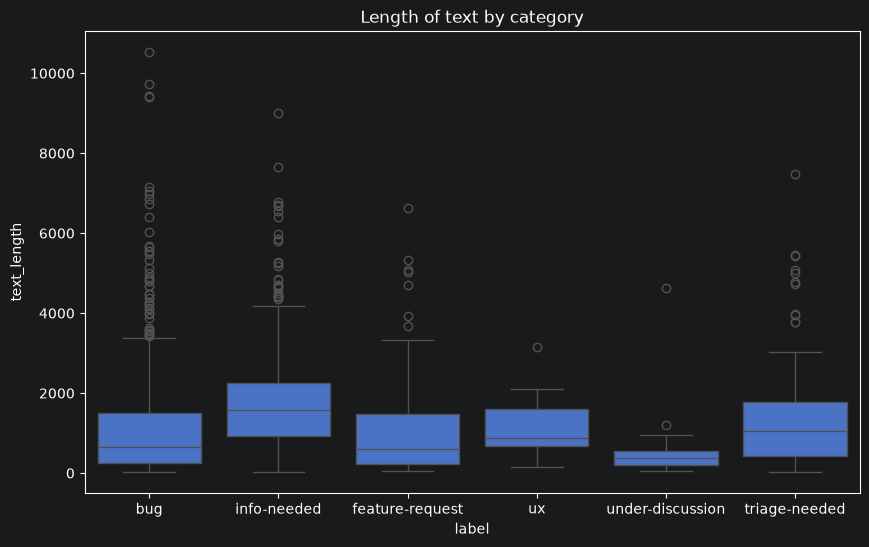

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="label", y="text_length")
plt.title("Length of text by category")
plt.show()

In [16]:
from collections import Counter
import re


def top_words(text_series, n=15):
    all_words = " ".join(text_series).lower()
    words = re.findall(r'\b[a-z]{3,}\b', all_words)
    stop_words = {"the", "and", "for", "this", "that", "with", "are", "was", "have"}
    words = [w for w in words if w not in stop_words]

    return Counter(words).most_common(n)

for label in df["label"].unique():
    subset = df[df["label"] == label]["text"]

    print(f"\n--- {label} ---")
    print(top_words(subset))


--- bug ---
[('vscode', 1540), ('code', 896), ('github', 825), ('src', 805), ('https', 723), ('com', 685), ('chat', 613), ('not', 565), ('version', 558), ('microsoft', 515), ('model', 464), ('extension', 433), ('copilot', 407), ('common', 401), ('agent', 366)]

--- info-needed ---
[('vscode', 3142), ('enabled', 2323), ('python', 2196), ('code', 1786), ('version', 1730), ('copilot', 854), ('java', 732), ('remote', 730), ('system', 716), ('model', 699), ('vscjava', 680), ('vendor', 615), ('device', 615), ('intel', 607), ('machine', 594)]

--- feature-request ---
[('chat', 151), ('model', 143), ('code', 120), ('when', 117), ('editor', 117), ('agent', 116), ('copilot', 114), ('vscode', 113), ('not', 108), ('file', 94), ('would', 90), ('should', 90), ('extension', 84), ('from', 83), ('user', 79)]

--- ux ---
[('chat', 58), ('feedback', 49), ('input', 46), ('editor', 45), ('session', 44), ('bar', 42), ('when', 39), ('not', 35), ('workbench', 34), ('compact', 31), ('modern', 30), ('context',